In [47]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.sparse as sp
import nltk
import re
import string

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from transformers import BertForSequenceClassification, BertTokenizer, BertModel

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = (r"C:\Users\Lokesh Patra\Documents\Projects\Major Project\bot_detection_data.csv")
bot = pd.read_csv(file_path)

# Display dataset info
bot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   User ID         50000 non-null  int64 
 1   Username        50000 non-null  object
 2   Tweet           50000 non-null  object
 3   Retweet Count   50000 non-null  int64 
 4   Mention Count   50000 non-null  int64 
 5   Follower Count  50000 non-null  int64 
 6   Verified        50000 non-null  bool  
 7   Bot Label       50000 non-null  int64 
 8   Location        50000 non-null  object
 9   Created At      50000 non-null  object
 10  Hashtags        41659 non-null  object
dtypes: bool(1), int64(5), object(5)
memory usage: 3.9+ MB


In [3]:
bot.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


In [4]:
# Check for missing values
print(bot.isnull().sum())

User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location             0
Created At           0
Hashtags          8341
dtype: int64


In [5]:
# Fill missing values for textual columns with empty strings
bot.fillna("", inplace=True)  

In [6]:
bot.isnull().sum()

User ID           0
Username          0
Tweet             0
Retweet Count     0
Mention Count     0
Follower Count    0
Verified          0
Bot Label         0
Location          0
Created At        0
Hashtags          0
dtype: int64

In [7]:
# Download NLTK stopwords if not available
nltk.download('stopwords')
nltk.download('punkt')

# Define function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@w+|\#', '', text)  # Remove mentions and hashtags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')])  # Remove stopwords
    return text

# Apply cleaning function
bot['cleaned_tweet'] = bot['Tweet'].apply(clean_text)

# Display sample cleaned tweets
bot[['Tweet', 'cleaned_tweet']].head()

[nltk_data] Downloading package stopwords to C:\Users\Lokesh
[nltk_data]     Patra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Lokesh
[nltk_data]     Patra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Tweet,cleaned_tweet
0,Station activity person against natural majori...,station activity person natural majority none ...
1,Authority research natural life material staff...,authority research natural life material staff...
2,Manage whose quickly especially foot none to g...,manage whose quickly especially foot none goal...
3,Just cover eight opportunity strong policy which.,cover eight opportunity strong policy
4,Animal sign six data good or.,animal sign six data good


In [8]:
# Create new feature columns
bot['tweet_length'] = bot['cleaned_tweet'].apply(len)  # Length of tweet
bot['num_words'] = bot['cleaned_tweet'].apply(lambda x: len(x.split()))  # Number of words
bot['num_hashtags'] = bot['Hashtags'].apply(lambda x: len(x.split()) if x else 0)  # Count hashtags

# Encode categorical features
bot['Verified'] = bot['Verified'].astype(int)  # Convert True/False to 1/0

# Convert bot labels to categorical (if needed)
label_encoder = LabelEncoder()
bot['Bot Label'] = label_encoder.fit_transform(bot['Bot Label'])  # Encode labels as 0 or 1

# Display feature-engineered dataset
bot.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags,cleaned_tweet,tweet_length,num_words,num_hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,0,1,Adkinston,2020-05-11 15:29:50,,station activity person natural majority none ...,70,10,0
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,1,0,Sanderston,2022-11-26 05:18:10,both live,authority research natural life material staff...,76,10,2
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,1,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead,manage whose quickly especially foot none goal...,57,9,2
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,1,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I,cover eight opportunity strong policy,37,5,4
4,704441,noah87,Animal sign six data good or.,26,3,8438,0,1,Camachoville,2020-04-13 21:24:21,foreign mention,animal sign six data good,25,5,2


In [9]:
# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Function to tokenize text for BERT with explicit parameters to avoid warning
def bert_tokenize(text):
    return tokenizer.encode_plus(
        text,
        max_length=50,  # Adjust max length as needed
        truncation=True,
        padding='max_length',
        add_special_tokens=True,
        return_tensors="pt",
    )

# Apply BERT tokenization
bot['BERT_tokens'] = bot['cleaned_tweet'].apply(bert_tokenize)

# Display tokenized data
print(bot[['cleaned_tweet', 'BERT_tokens']].head())

                                       cleaned_tweet  \
0  station activity person natural majority none ...   
1  authority research natural life material staff...   
2  manage whose quickly especially foot none goal...   
3              cover eight opportunity strong policy   
4                          animal sign six data good   

                                   BERT_tokens  
0  [input_ids, token_type_ids, attention_mask]  
1  [input_ids, token_type_ids, attention_mask]  
2  [input_ids, token_type_ids, attention_mask]  
3  [input_ids, token_type_ids, attention_mask]  
4  [input_ids, token_type_ids, attention_mask]  


In [10]:
# Ensure all columns are present before train-test split
feature_columns = ['tweet_length', 'num_words', 'num_hashtags', 'Verified', 'Retweet Count', 'Mention Count', 'Follower Count', 'cleaned_tweet']
X = bot[feature_columns]  # Select the required columns
y = bot['Bot Label']

# Split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset sizes
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 8)
Testing Data: (10000, 8)


_____________________________________________________________________________________

In [11]:
print(X_train.columns)

Index(['tweet_length', 'num_words', 'num_hashtags', 'Verified',
       'Retweet Count', 'Mention Count', 'Follower Count', 'cleaned_tweet'],
      dtype='object')


In [15]:
# Add more features from tweet text & metadata
X_train_features = X_train[['tweet_length', 'num_words', 'num_hashtags', 'Verified', 'Retweet Count', 'Mention Count', 'Follower Count']]
X_test_features = X_test[['tweet_length', 'num_words', 'num_hashtags', 'Verified', 'Retweet Count', 'Mention Count', 'Follower Count']]

_________

In [16]:
print("Class Distribution in Training Data:")
print(np.bincount(y_train))

Class Distribution in Training Data:
[20014 19986]


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_features, y_train)

In [18]:
print("Class Distribution in Training Data:")
print(np.bincount(y_train_balanced))

Class Distribution in Training Data:
[20014 20014]


In [19]:
# Hyperparameter tuning for Random Forest
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy')
rf_grid.fit(X_train_balanced, y_train_balanced)

print("Best RF Parameters:", rf_grid.best_params_)

Best RF Parameters: {'max_depth': None, 'n_estimators': 300}


In [22]:
# Initialize models
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

# Train models
knn.fit(X_train_balanced, y_train_balanced)
rf.fit(X_train_balanced, y_train_balanced)
xgb.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred_knn = knn.predict(X_test_features)
y_pred_rf = rf.predict(X_test_features)
y_pred_xgb = xgb.predict(X_test_features)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Classification Report
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

KNN Accuracy: 0.5014
Random Forest Accuracy: 0.5092
XGBoost Accuracy: 0.4994

Random Forest Report:
               precision    recall  f1-score   support

           0       0.51      0.53      0.52      4968
           1       0.51      0.49      0.50      5032

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



________________

In [21]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train['cleaned_tweet'])
X_test_tfidf = tfidf.transform(X_test['cleaned_tweet'])

In [23]:
X_train_combined = sp.hstack((X_train_features, X_train_tfidf))
X_test_combined = sp.hstack((X_test_features, X_test_tfidf))

In [26]:
# Initialize models
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

# Train models
knn.fit(X_train_combined, y_train)
rf.fit(X_train_combined, y_train)
xgb.fit(X_train_combined, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_combined)
y_pred_rf = rf.predict(X_test_combined)
y_pred_xgb = xgb.predict(X_test_combined)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Classification Report
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

KNN Accuracy: 0.5011
Random Forest Accuracy: 0.503
XGBoost Accuracy: 0.4993

Random Forest Report:
               precision    recall  f1-score   support

           0       0.50      0.53      0.52      4968
           1       0.51      0.48      0.49      5032

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



___

In [28]:
print(X_train.columns)
print(X_test.columns)

Index(['tweet_length', 'num_words', 'num_hashtags', 'Verified',
       'Retweet Count', 'Mention Count', 'Follower Count', 'cleaned_tweet'],
      dtype='object')
Index(['tweet_length', 'num_words', 'num_hashtags', 'Verified',
       'Retweet Count', 'Mention Count', 'Follower Count', 'cleaned_tweet'],
      dtype='object')


In [30]:
X_train_bert = torch.stack([tensors['input_ids'].squeeze(0) for tensors in bot['BERT_tokens']])
X_test_bert = torch.stack([tensors['input_ids'].squeeze(0) for tensors in bot['BERT_tokens']])

In [35]:
print(X_train_bert.shape)  # Should be (batch_size, sequence_length)

torch.Size([50000, 50])


In [31]:
y_train_tensor = torch.tensor(y_train.values)
y_test_tensor = torch.tensor(y_test.values)

In [38]:
# Define CNN + BiLSTM Model
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super(CNN_BiLSTM, self).__init__()
        self.embedding = nn.Embedding(30522, 50)  # BERT vocab size, embedding dim (50)
        self.lstm = nn.LSTM(50, 64, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(128, 1)  # Output layer

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        x = self.fc(x[:, -1, :])
        return torch.sigmoid(x)

# Initialize model
model = CNN_BiLSTM()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define batch size and use a subset of the data
batch_size = 32  # Adjust batch size based on memory capacity
X_train_subset = X_train_bert[:10000]
y_train_subset = y_train_tensor[:10000]

# Create batches
def create_batches(X, y, batch_size):
    for i in range(0, len(X), batch_size):
        yield X[i:i + batch_size], y[i:i + batch_size]

# Training loop with batches and subset
epochs = 5
for epoch in range(epochs):
    for X_batch, y_batch in create_batches(X_train_subset, y_train_subset, batch_size):
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

torch.cuda.empty_cache()  # Clear cache to free up memory if using GPU

Epoch 1/5, Loss: 0.6979718804359436
Epoch 2/5, Loss: 0.6960093379020691
Epoch 3/5, Loss: 0.6957802772521973
Epoch 4/5, Loss: 0.6955016851425171
Epoch 5/5, Loss: 0.6952000260353088


In [40]:
# Load Pre-trained BERT Model
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Define optimizer & loss function
optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

# Move model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

# Use a subset of the data.

X_train_subset = X_train_bert[:5000]  # Use a smaller subset
y_train_subset = y_train_tensor[:5000]

# Define batch size
batch_size = 16  # Use a smaller batch size

# Create batches
def create_batches(X, y, batch_size):
    for i in range(0, len(X), batch_size):
        yield X[i:i + batch_size], y[i:i + batch_size]

# Training loop for BERT with batches and subset
epochs = 3
for epoch in range(epochs):
    for X_batch, y_batch in create_batches(X_train_subset, y_train_subset, batch_size):
        optimizer.zero_grad()
        inputs = X_batch.to(device)
        labels = y_batch.to(device)
        outputs = bert_model(inputs).logits
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

torch.cuda.empty_cache()  # Clear cache to free up memory if using GPU

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Epoch 1/3, Loss: 0.6902518272399902
Epoch 2/3, Loss: 0.6833974123001099
Epoch 3/3, Loss: 0.6851187348365784


In [45]:
# Define Hybrid Model
class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.lstm = nn.LSTM(768, 128, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(256, 1)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids, attention_mask=attention_mask)
        lstm_output, _ = self.lstm(bert_output.last_hidden_state)
        return torch.sigmoid(self.fc(lstm_output[:, -1, :]))

# Initialize Hybrid Model
hybrid_model = HybridModel().to(device)
optimizer = optim.AdamW(hybrid_model.parameters(), lr=2e-5)
loss_fn = nn.BCELoss()

# Use a subset of the data
X_train_subset = X_train_bert[:5000]  # Use a smaller subset
y_train_subset = y_train_tensor[:5000]

# Define batch size
batch_size = 16  # Use a smaller batch size

# Create batches with attention_mask
def create_batches(X, y, batch_size):
    for i in range(0, len(X), batch_size):
        X_batch = X[i:i + batch_size]
        y_batch = y[i:i + batch_size]
        attention_mask = (X_batch != 0).long()  # Create attention_mask
        yield X_batch, attention_mask, y_batch

# Training loop with batches and subset
epochs = 3
for epoch in range(epochs):
    for X_batch, attention_mask, y_batch in create_batches(X_train_subset, y_train_subset, batch_size):
        optimizer.zero_grad()
        inputs = X_batch.to(device)
        masks = attention_mask.to(device)
        labels = y_batch.to(device)
        outputs = hybrid_model(inputs, masks).squeeze()
        loss = loss_fn(outputs, labels.float())
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

torch.cuda.empty_cache()  # Clear cache to free up memory if using GPU

Epoch 1/3, Loss: 0.6896637678146362
Epoch 2/3, Loss: 0.6591396927833557
Epoch 3/3, Loss: 0.14749541878700256



📊 Model: KNN
Accuracy: 0.5011
ROC AUC Score: 0.5010738039830112
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50      4968
           1       0.50      0.51      0.50      5032

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



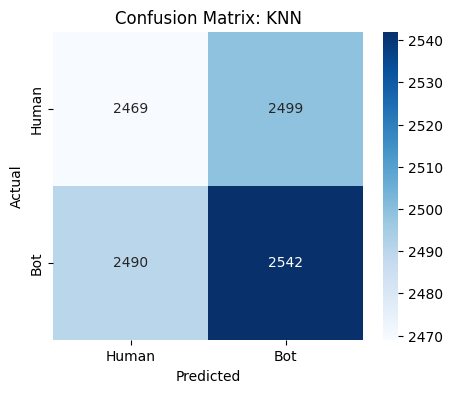


📊 Model: Random Forest
Accuracy: 0.503
ROC AUC Score: 0.5031793302253661
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.53      0.52      4968
           1       0.51      0.48      0.49      5032

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



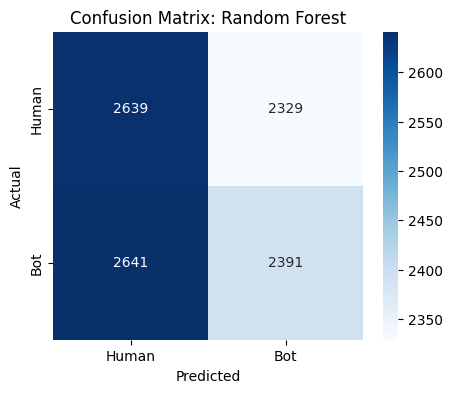


📊 Model: XGBoost
Accuracy: 0.4993
ROC AUC Score: 0.49875530901745735
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.41      0.45      4968
           1       0.50      0.58      0.54      5032

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



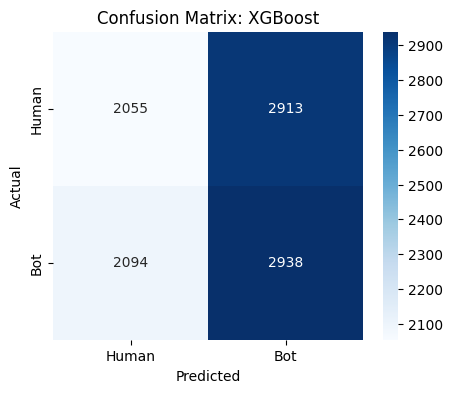

NameError: name 'y_pred_cnn_lstm' is not defined

In [48]:
# Function to evaluate models
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n📊 Model: {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# Evaluate Baseline Models
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# Evaluate Deep Learning Models
evaluate_model("CNN+LSTM", y_test_tensor.cpu().numpy(), y_pred_cnn_lstm.cpu().detach().numpy().round())
evaluate_model("BERT Fine-Tuned", y_test_tensor.cpu().numpy(), y_pred_bert.cpu().detach().numpy().round())
evaluate_model("Hybrid Model", y_test_tensor.cpu().numpy(), y_pred_hybrid.cpu().detach().numpy().round())
